In [2]:
from pathlib import Path
import pandas as pd
import networkx as nx

file = Path("../data/repeated_10_scale_250/100206_repeated10_scale250.graphml")

node_num_cols = [
    "dn_position_x", "dn_position_y", "dn_position_z", "dn_correspondence_id"
]

edge_num_cols = [
    "fiber_length_mean", "FA_mean", "number_of_fibers"
]

G = nx.read_graphml(file)

node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append({
        "file": file.name,
        "path": str(file),
        "node_id": node_id,
        **attrs
    })

nodes_df = pd.DataFrame(node_records)

for col in node_num_cols:
    if col in nodes_df.columns:
        nodes_df[col] = pd.to_numeric(nodes_df[col], errors="coerce")

edge_records = []
for u, v, attrs in G.edges(data=True):
    edge_records.append({
        "file": file.name,
        "path": str(file),
        "source": u,
        "target": v,
        **attrs
    })

edges_df = pd.DataFrame(edge_records)

for col in edge_num_cols:
    if col in edges_df.columns:
        edges_df[col] = pd.to_numeric(edges_df[col])


display(nodes_df.head())
display(edges_df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/repeated_10_scale_250/100206_repeated10_scale250.graphml'

In [9]:
nodes_df.head()

,file,path,node_id,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere
0,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,1,36.000000,74.143590,7.584615,1,cortical,lateralorbitofrontal_1,rh.lateralorbitofrontal_1,right
1,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,29.917241,78.565517,13.675862,2,cortical,lateralorbitofrontal_2,rh.lateralorbitofrontal_2,right
2,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,3,28.670673,80.062500,7.425481,3,cortical,lateralorbitofrontal_3,rh.lateralorbitofrontal_3,right
3,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,4,36.979933,79.662207,7.926421,4,cortical,lateralorbitofrontal_4,rh.lateralorbitofrontal_4,right
4,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,5,37.913043,85.681159,7.526570,5,cortical,lateralorbitofrontal_5,rh.lateralorbitofrontal_5,right


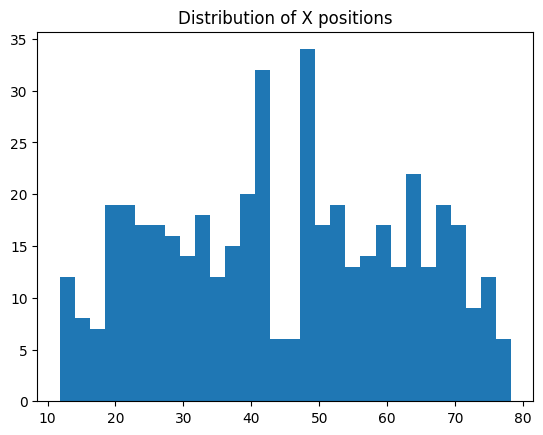

In [10]:
import matplotlib.pyplot as plt

plt.hist(nodes_df["dn_position_x"], bins=30)
plt.title("Distribution of X positions")
plt.show()

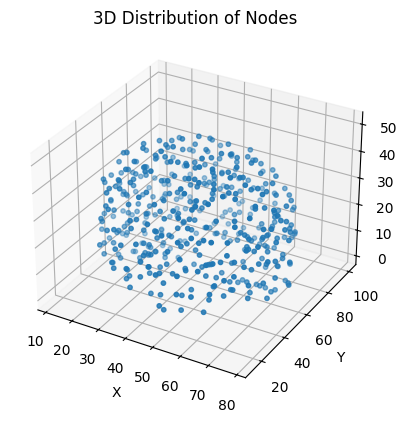

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    nodes_df["dn_position_x"],
    nodes_df["dn_position_y"],
    nodes_df["dn_position_z"],
    s=10
)

ax.set_title("3D Distribution of Nodes")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

# nodes are distributed across space rather than concentrated in a single region
# no obvious clustering in one specific area, suggesting a relatively spread spatial organization of the brain regions

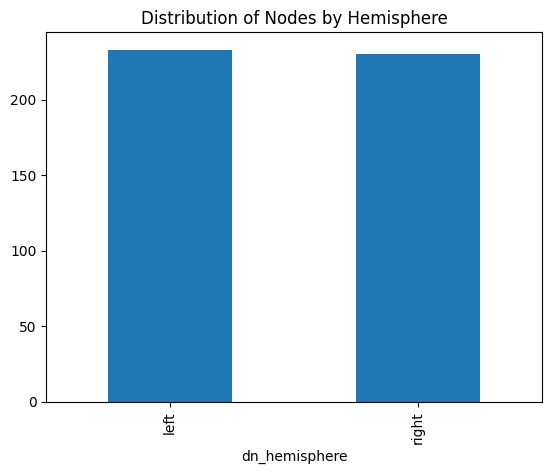

In [ ]:
nodes_df["dn_hemisphere"].value_counts().plot(kind="bar")
plt.title("Distribution of Nodes by Hemisphere")
plt.show()

# balanced number of nodes between right and left hemeshere

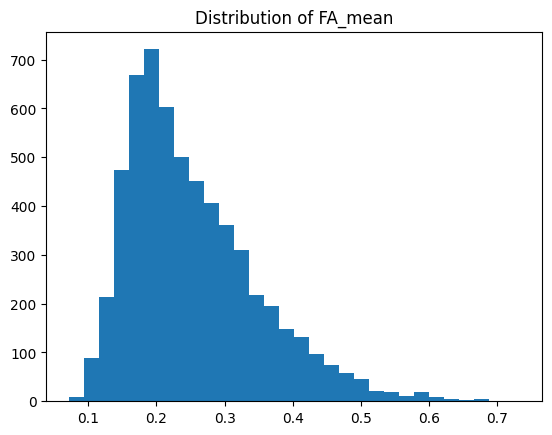

In [ ]:
plt.hist(edges_df["FA_mean"], bins=30)
plt.title("Distribution of FA_mean")
plt.show()

# FA - how strong and organized nodes' connections are (low FA --> messy, weak connection)
# the distribution of FA values is right-skewed, with most connections having relatively 
# low to moderate values and only a few strong connections.
